In [1]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import glob
import os

all_files = sorted(glob.glob("../citibike_2025/*.csv"))
files = all_files  # ALL csvs, no filtering

print(f"Using {len(files)} CSV files:")
for f in files:
    print(f"  {os.path.basename(f)}")

total_mb = sum(os.path.getsize(f) for f in files) / 1024 / 1024
print(f"\nTotal CSV size: {total_mb:.0f} MB ({total_mb/1024:.2f} GB)")

KEEP_COLS = [
    "rideable_type", "started_at", "ended_at",
    "start_station_name", "start_lat", "start_lng",
    "end_station_name", "end_lat", "end_lng",
    "member_casual"
]

dfs = []
for f in files:
    print(f"Loading {os.path.basename(f)}...")
    dfs.append(pd.read_csv(f, usecols=KEEP_COLS, low_memory=False))

df = pd.concat(dfs, ignore_index=True)

print(f"\n=== REAL STATS FOR YOUR SLIDE ===")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB in pandas")
print(f"Unique start stations: {df['start_station_name'].nunique()}")
print(f"Member/casual split:\n{df['member_casual'].value_counts()}")
print(f"Rideable type split:\n{df['rideable_type'].value_counts()}")

table = pa.Table.from_pandas(df, preserve_index=False)
pq.write_table(table, "citibike_2025_full.parquet")
print(f"Saved: {os.path.getsize('citibike_2025_full.parquet')/1024**2:.0f} MB")

Using 53 CSV files:
  202501-citibike-tripdata_1.csv
  202501-citibike-tripdata_2.csv
  202501-citibike-tripdata_3.csv
  202502-citibike-tripdata_1.csv
  202502-citibike-tripdata_2.csv
  202502-citibike-tripdata_3.csv
  202503-citibike-tripdata_1.csv
  202503-citibike-tripdata_2.csv
  202503-citibike-tripdata_3.csv
  202503-citibike-tripdata_4.csv
  202504-citibike-tripdata_1.csv
  202504-citibike-tripdata_2.csv
  202504-citibike-tripdata_3.csv
  202504-citibike-tripdata_4.csv
  202505-citibike-tripdata_1.csv
  202505-citibike-tripdata_2.csv
  202505-citibike-tripdata_3.csv
  202505-citibike-tripdata_4.csv
  202505-citibike-tripdata_5.csv
  202506-citibike-tripdata_1.csv
  202506-citibike-tripdata_2.csv
  202506-citibike-tripdata_3.csv
  202506-citibike-tripdata_4.csv
  202506-citibike-tripdata_5.csv
  202507-citibike-tripdata_1.csv
  202507-citibike-tripdata_2.csv
  202507-citibike-tripdata_3.csv
  202507-citibike-tripdata_4.csv
  202507-citibike-tripdata_5.csv
  202508-citibike-tripd

In [2]:
import pandas as pd

df = pd.read_parquet("citibike_2025_sampled.parquet")

df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
df["hour"] = df["started_at"].dt.hour
df["dayofweek"] = df["started_at"].dt.dayofweek
df["is_weekend"] = df["dayofweek"] >= 5
df["duration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

df_full = df.copy()  # keep full year if needed later
df = df[df["started_at"].dt.month == 7]  # July only for mockups

print(f"Loaded {len(df):,} rows")
print(df.dtypes)

Loaded 999,714 rows
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
end_station_name                 str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
hour                           int32
dayofweek                      int32
is_weekend                      bool
duration_min                 float64
dtype: object


In [3]:
import plotly.graph_objects as go
import pandas as pd

# Pick a specific hour to show — 8am is the most dramatic
HOUR = 8

hour_df = df[df["hour"] == HOUR]

# Top flows by volume
flows = (
    hour_df.groupby([
        "start_station_name", "start_lat", "start_lng",
        "end_station_name", "end_lat", "end_lng"
    ])
    .size()
    .reset_index(name="trips")
    .sort_values("trips", ascending=False)
    .head(100)  # top 100 flows only — otherwise it's unreadable
)

# Normalize line width
flows["width"] = 1 + 5 * (flows["trips"] - flows["trips"].min()) / (flows["trips"].max() - flows["trips"].min())

fig = go.Figure()

# Draw one line per flow
for _, row in flows.iterrows():
    fig.add_trace(go.Scattermapbox(
        lon=[row["start_lng"], row["end_lng"], None],
        lat=[row["start_lat"], row["end_lat"], None],
        mode="lines",
        line=dict(width=row["width"], color="rgba(79, 195, 247, 0.4)"),
        hoverinfo="skip",
        showlegend=False
    ))

# Add station dots on top
stations = (
    hour_df.groupby(["start_station_name", "start_lat", "start_lng"])
    .size()
    .reset_index(name="trips")
)

fig.add_trace(go.Scattermapbox(
    lat=stations["start_lat"],
    lon=stations["start_lng"],
    mode="markers",
    marker=dict(
        size=stations["trips"] / stations["trips"].max() * 15 + 3,
        color=stations["trips"],
        colorscale="Plasma",
        showscale=True,
        colorbar=dict(title="Trips", tickfont=dict(color="white"))
    ),
    text=stations["start_station_name"],
    hovertemplate="<b>%{text}</b><br>Trips: %{marker.color}<extra></extra>",
    showlegend=False
))

fig.update_layout(
    mapbox=dict(
        style="carto-darkmatter",
        center={"lat": 40.74, "lon": -73.99},
        zoom=12
    ),
    paper_bgcolor="#1a1a2e",
    font_color="white",
    title=f"Flow Network at {HOUR}:00 — Top 100 Station Flows",
    height=650,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

/tmp/ipykernel_2117523/2606015600.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/tmp/ipykernel_2117523/2606015600.py:44: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
import plotly.express as px

# Build edge list — trips between stations
edges = (
    df.groupby(["start_station_name", "end_station_name"])
    .size()
    .reset_index(name="weight")
)

# Remove self-loops
edges = edges[edges["start_station_name"] != edges["end_station_name"]]

# Only keep edges with meaningful volume to avoid noise
edges = edges[edges["weight"] >= 50]

# Build graph
G = nx.from_pandas_edgelist(
    edges,
    source="start_station_name",
    target="end_station_name",
    edge_attr="weight"
)

# Run Louvain community detection
partition = community_louvain.best_partition(G, weight="weight")

# Get station coordinates
station_coords = (
    df.groupby("start_station_name")[["start_lat", "start_lng"]]
    .mean()
    .reset_index()
)
station_coords.columns = ["station", "lat", "lng"]

# Attach community labels
station_coords["community"] = station_coords["station"].map(partition)

# Drop stations not in graph
station_coords = station_coords.dropna(subset=["community"])
station_coords["community"] = station_coords["community"].astype(str)

# Keep only top N communities by size for readability
top_communities = (
    station_coords["community"]
    .value_counts()
    .head(6)
    .index
)
station_coords = station_coords[station_coords["community"].isin(top_communities)]

fig = px.scatter_mapbox(
    station_coords,
    lat="lat",
    lon="lng",
    color="community",
    hover_name="station",
    zoom=11,
    center={"lat": 40.74, "lon": -73.99},
    mapbox_style="carto-darkmatter",
    title="Functional Neighborhoods — How NYC Organizes Itself",
    height=600,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.update_layout(
    paper_bgcolor="#1a1a2e",
    font_color="white",
    legend_title="Community"
)

fig.show()

/tmp/ipykernel_2117523/2909094621.py:55: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [5]:
# Mock 3
import plotly.graph_objects as go

# Daily trip counts
daily = (
    df.groupby(df["started_at"].dt.date)
    .size()
    .reset_index(name="trips")
)
daily.columns = ["date", "trips"]
daily["date"] = pd.to_datetime(daily["date"])
daily["weekday"] = daily["date"].dt.weekday
daily["week"] = daily["date"].dt.isocalendar().week.astype(int)
daily["deviation"] = (daily["trips"] - daily["trips"].mean()) / daily["trips"].std()
daily["label"] = daily["date"].dt.strftime("%b %d")

fig = go.Figure(go.Heatmap(
    x=daily["week"],
    y=daily["weekday"],
    z=daily["deviation"],
    text=daily["label"],
    hovertemplate="<b>%{text}</b><br>Deviation: %{z:.2f}σ<extra></extra>",
    colorscale="RdYlGn",
    zmid=0,
    colorbar=dict(title="Deviation from mean", tickfont=dict(color="white"))
))

fig.update_layout(
    title="When Does the City Break Its Pattern?",
    paper_bgcolor="#1a1a2e",
    plot_bgcolor="#1a1a2e",
    font_color="white",
    yaxis=dict(
        tickvals=[0,1,2,3,4,5,6],
        ticktext=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    ),
    xaxis_title="Week",
    height=400
)

fig.show()

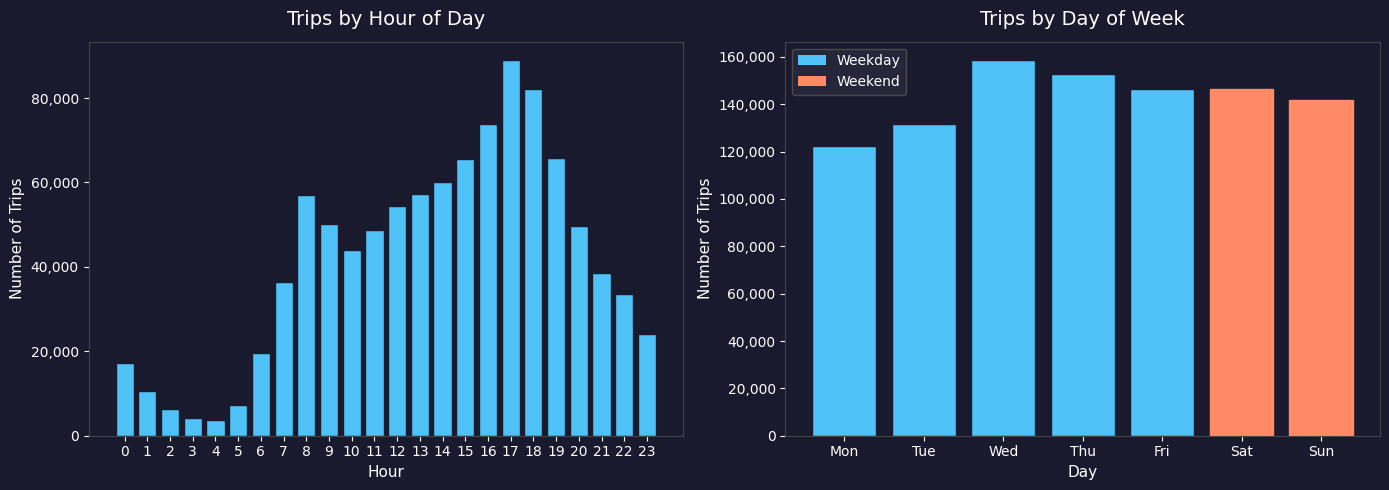

In [8]:
# EDA
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#1a1a2e")

# Plot 1: Trips by hour of day
hourly = df.groupby("hour").size()

ax1 = axes[0]
ax1.set_facecolor("#1a1a2e")
ax1.bar(hourly.index, hourly.values, color="#4FC3F7", edgecolor="#1a1a2e")
ax1.set_title("Trips by Hour of Day", color="white", fontsize=14, pad=12)
ax1.set_xlabel("Hour", color="white", fontsize=11)
ax1.set_ylabel("Number of Trips", color="white", fontsize=11)
ax1.set_xticks(range(0, 24))
ax1.tick_params(colors="white")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax1.spines.values():
    spine.set_color("#444")

# Plot 2: Trips by day of week
dow = df.groupby("dayofweek").size()
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
bars = ax2.bar(days, dow.values, color="#4FC3F7", edgecolor="#1a1a2e")

# Highlight weekends
for i, bar in enumerate(bars):
    if i >= 5:
        bar.set_color("#FF8A65")

ax2.set_title("Trips by Day of Week", color="white", fontsize=14, pad=12)
ax2.set_xlabel("Day", color="white", fontsize=11)
ax2.set_ylabel("Number of Trips", color="white", fontsize=11)
ax2.tick_params(colors="white")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax2.spines.values():
    spine.set_color("#444")

# Legend for weekend highlight
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4FC3F7", label="Weekday"),
    Patch(facecolor="#FF8A65", label="Weekend")
]
ax2.legend(handles=legend_elements, facecolor="#2a2a3e",
           edgecolor="#555", labelcolor="white", fontsize=10)

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, facecolor="#1a1a2e", bbox_inches="tight")
plt.show()